# Part 4: Segment cells, extracellular matrix, and nuclei.

In the following notebook you will use the Instanseg algorithm to perfom cellular, extracellular matrix, and nuclear segmentation.

## 1. Import packages. 
This must be done every time the notebook is started or restarted.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
import tifffile as tiff
from skimage import io
import Kview2
import numpy as np
import stackview
import pandas as pd
from napari_simpleitk_image_processing import label_statistics
from scipy import ndimage
from skimage.transform import resize
import matplotlib.pyplot as plt
from matplotlib import rc_file_defaults

## 2. Define directory paths. 
*This must be done every time the notebook is started or restarted.

### 2.1 Define directories

In [2]:
base_dir = "C:\\Users\\smith6jt"

In [3]:
seg_dir = os.path.join(base_dir, 'KINTSUGI', 'data', '1904_CC2B_Segmentation')
proc_dir = seg_dir.replace('_Segmentation', '_Processed')
clus_dir = seg_dir.replace('_Segmentation', '_Clustering')
print(f"Segmentation folder is {seg_dir}.")
print(f"Processed folder is {proc_dir}.")
print(f"Clustering folder is {clus_dir}.")

Segmentation folder is C:\Users\smith6jt\KINTSUGI\data\1904_CC2B_Segmentation.
Processed folder is C:\Users\smith6jt\KINTSUGI\data\1904_CC2B_Processed.
Clustering folder is C:\Users\smith6jt\KINTSUGI\data\1904_CC2B_Clustering.


### 2.2 Create directories

This cell only needs to be run once.

In [4]:
os.makedirs(seg_dir, exist_ok=True)
os.makedirs(clus_dir, exist_ok=True)

## 3. Run Instanseg

See documentation at https://github.com/instanseg/instanseg/tree/main

In [ ]:
# Options for bioio readers are: arraylike, ome-tiff, ome-tiled-tiff, ome-zarr, bioformats, tifffile, imageio, tiff-glob
# Options for image_reader are: "tiffslide", "skimage.io", "bioio", "AICSImageIO"
from instanseg import InstanSeg
pixel_size = 0.3774
instanseg_fluorescence = InstanSeg("fluorescence_nuclei_and_cells", verbosity=1, image_reader = "skimage.io")

### 3.1 Segment nuclei or cells.

- For smaller images, use "eval"
- Change the imported image to segment cells
- Even when segmenting nuclei only, the target should stay "cells"

In [ ]:
image_array_nuc, pixel_size = instanseg_fluorescence.read_image(os.path.join(proc_dir, 'DAPI.tif'))
labeled_output_nuc, image_tensor_nuc  = instanseg_fluorescence.eval_medium_image(image_array_nuc, normalise=True, pixel_size=pixel_size, target= "cells")
display_nuc = instanseg_fluorescence.display(image_tensor_nuc, labeled_output_nuc)

### 3.2 Segment cells and nuclei.

In [ ]:
image_array_cells, pixel_size = instanseg_fluorescence.read_image(os.path.join(proc_dir, "1904_CC2B.tif"))
labeled_output_cells, image_tensor_cells  = instanseg_fluorescence.eval_medium_image(image_array_cells, normalise=True, pixel_size=pixel_size, resolve_cell_and_nucleus=True, cleanup_fragments = True, target= "all_outputs")
display_cells = instanseg_fluorescence.display(image_tensor_cells, labeled_output_cells)

## 4. Inspect and save segmentation results 

### 4.1 Visualize segmentation masks

In [ ]:
from instanseg.utils.utils import show_images
show_images(display_cells[7500:None, 8000:None, :], colorbar=True)

### 4.2 Save labeled masks

In [ ]:
instanseg_fluorescence.save_output(os.path.join(seg_dir,"cells"), labeled_output_cells, image_tensor_cells, save_overlay=True)

## 5. Segment extracellular space

### 5.1 Read in labeled mask and marker for evaluation

In [ ]:
marker_name = "1904_CC2B"

marker = tiff.imread(os.path.join(proc_dir, f"{marker_name}.tif"))
marker_mask = tiff.imread(os.path.join(seg_dir, f"cells_instanseg_prediction.tiff"))

In [ ]:
marker_image = marker.astype(np.uint16)
marker_label = marker_mask[1].astype(np.uint32)

x1 = 1200
x2 = 2100
y1 = 4300
y2 = 5200

Kview2.curtain(marker_image[0,y1:y2,x1:x2], marker_label[y1:y2,x1:x2], alpha=0.6, zoom_factor=0.8, colormap='turbo')

In [ ]:
nuclear_marker = tiff.imread(os.path.join(proc_dir, "DAPI.tif"))
nuclear_mask = marker_mask[0]
nuclear_image = nuclear_marker.astype(np.uint16)
nuclear_label = nuclear_mask.astype(np.uint32)

x1 = 1200
x2 = 2100
y1 = 4300
y2 = 5200

Kview2.curtain(nuclear_image[y1:y2,x1:x2], nuclear_label[y1:y2,x1:x2], alpha=0.6, zoom_factor=0.8, colormap='grey')

### 5.2 Create matched watershed masks for each labeled cell

In [ ]:
from skimage.segmentation import watershed
binary_mask = marker_label > 0

distance = ndimage.distance_transform_edt(~binary_mask)

ecm_segmentation = watershed(distance, marker_label)
ecm_segmentation[marker_label > 0]=0

### 5.3 Visualize and save results

In [ ]:
x1 = 1200
x2 = 2100
y1 = 4300
y2 = 5200

stackview.curtain(marker_image[4,y1:y2,x1:x2], ecm_segmentation[1,y1:y2,x1:x2], alpha=0.6, zoom_factor=0.8, colormap='turbo')

In [ ]:
tiff.imwrite(os.path.join(seg_dir, f"ecm_segmentation.tiff"), ecm_segmentation)

## 6. Extract segmentation data

### 6.1 Choose cell features and create dataframe

In [ ]:
marker_names = [ 'CD3e', 'CD15', 'CD20', 'CD68', 'DAPI', 'Ki67', 'SMActin']
marker_stats = {}
marker_position_stats = label_statistics(intensity_image=None, 
                            label_image=marker_label,
                            size=True,
                            intensity=False,
                            perimeter=True,
                            shape=True,
                            position=True,
                            moments=False)

for stat_name, values in marker_position_stats.items():
        new_col_name = f"cell_{stat_name}"
        marker_stats[new_col_name] = values

for i, marker_name in enumerate(marker_names):
    stats = label_statistics(marker[i], 
                           marker_label,
                           size=False,
                           intensity=True,
                           perimeter=False,
                           shape=False,
                           position=False,
                           moments=True)
    
    for stat_name, values in stats.items():
        new_col_name = f"cell_{marker_name}_{stat_name}"
        marker_stats[new_col_name] = values

cell_df = pd.DataFrame(marker_stats)
cell_path = os.path.join(seg_dir, 'cell_stats.csv')
cell_df.to_csv(cell_path, index=False)
print(f"DataFrame shape: {cell_df.shape}")

### 6.2 Choose nuclear features and create dataframe

In [ ]:
marker_names =[ 'CD3e', 'CD15', 'CD20', 'CD68', 'DAPI', 'Ki67', 'SMActin']
nuclear_stats = {}
# Use nuclear positions for nuclear measurements
nuclear_position_stats = label_statistics(intensity_image=None, 
                            label_image=nuclear_label,
                            size=True,
                            intensity=False,
                            perimeter=False,
                            shape=False,
                            position=True,
                            moments=False)

for stat_name, values in nuclear_position_stats.items():
        new_col_name = f"nuclear_{stat_name}"
        nuclear_stats[new_col_name] = values

for i, marker_name in enumerate(marker_names):
    stats = label_statistics(marker[i], 
                           nuclear_label,
                           size=False,
                           intensity=True,
                           perimeter=False,
                           shape=False,
                           position=False,
                           moments=True)
    
    for stat_name, values in stats.items():
        new_col_name = f"{marker_name}_{stat_name}"
        nuclear_stats[new_col_name] = values

nuclear_df = pd.DataFrame(nuclear_stats)
nuclear_path = os.path.join(seg_dir, 'nuclear_stats.csv')
nuclear_df.to_csv(nuclear_path, index=False)
print(f"DataFrame shape: {nuclear_df.shape}")

### 6.3 Choose extracellular matrix features and create dataframe

In [ ]:
ecm_segmentation.shape

In [ ]:
marker_names =[ 'CD3e', 'CD15', 'CD20', 'CD68', 'DAPI', 'Ki67', 'SMActin']
ecm_stats = {}
ecm_position_stats = label_statistics(intensity_image=None, 
                            label_image=ecm_segmentation,
                            size=True,
                            intensity=False,
                            perimeter=True,
                            shape=True,
                            position=True,
                            moments=False)

for ecm_position_stat_name, ecm_position_values in ecm_position_stats.items():
        new_col_name = f"ECM_{ecm_position_stat_name}"
        ecm_stats[new_col_name] = ecm_position_values
        
for i, marker_name in enumerate(marker_names):
    ecm_marker_stats = label_statistics(marker[i], 
                           ecm_segmentation,
                           size=False,
                           intensity=True,
                           perimeter=False,
                           shape=False,
                           position=False,
                           moments=True)

    for ecm_stat_name, ecm_values in ecm_marker_stats.items():
        ecm_new_col_name = f"ECM_{marker_name}_{ecm_stat_name}"
        ecm_stats[ecm_new_col_name] = ecm_values


ecm_df = pd.DataFrame(ecm_stats)
ecm_path = os.path.join(seg_dir, 'ecm_stats.csv')
ecm_df.to_csv(ecm_path, index=False)
print(f"DataFrame shape: {ecm_df.shape}")

### 6.4 Plot marker intensities

Open the images and segmentation masks in napari for inspection.  To generate measurements, go to Tools>Measurement>Plot Measurement.  For more options see https://github.com/BiAPoL/napari-clusters-plotter/tree/main

In [ ]:
import napari
viewer = napari.Viewer()

viewer.add_image(marker_image)

viewer.add_labels(marker_mask)
viewer.add_labels(nuclear_mask)

viewer.add_labels(ecm_segmentation)

## 7. Self-organizing map clustering

### 7.1 Define plot function

In [ ]:
import pyFlowSOM
import seaborn as sns
from matplotlib.colors import ListedColormap
from tqdm.notebook import tqdm
from sklearn.preprocessing import StandardScaler

# Initialize the scaler

def visualize_som(pixel_data: None, 
                  channels: list,
                         image: str,
                         channel_vis: str,
                         num_nodes: int = 10, 
                         num_passes: int = 5,
                         lr_start: float = 0.05,
                         lr_end: float = 0.01,
                         live_plots: bool = False):
    scaler = StandardScaler()
    grid_size = int(np.sqrt(num_nodes))
    train_data = pixel_data[channels].copy()
    train_data['centroid_0'] = pixel_data['centroid_0']
    train_data['centroid_1'] = pixel_data['centroid_1']
    train_array_pre = pixel_data[channels].values.astype(np.float64)
    train_array = scaler.fit_transform(train_array_pre)
    colors = sns.color_palette("tab20", n_colors=num_nodes)
    node_cmap = ListedColormap(colors)

    pbar_filesave = tqdm(total=100, unit="Percent",
                    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]',
                    colour="green", position=0, leave=True)

    scatter_frames = []
    for rlen_iter in range(1, num_passes + 1):

        som = pyFlowSOM.som(train_array, grid_size, grid_size, rlen_iter, alpha_range=(lr_start, lr_end), seed=627)
        clusters, dist = pyFlowSOM.map_data_to_nodes(som, train_array)

        unique_clusters = np.unique(clusters)
        cluster_map = {old: new for new, old in enumerate(unique_clusters)}
        clusters = np.array([cluster_map[c] for c in clusters])
        train_data['cluster'] = clusters
        
        df_mean = train_data.groupby(['cluster']).mean()
        df_mean = df_mean.drop(columns=['centroid_0', 'centroid_1'])
        df_mean.index = [f'Cluster_{i+1}' for i in range(len(df_mean))]
        fig, axes = plt.subplots(1, 3, figsize=(21, 7))

        im = axes[0].imshow(image, vmax=np.percentile(image, 99.9), cmap='turbo')
        fig.colorbar(im, shrink=0.5, ax=axes[0], cmap=node_cmap)
        axes[0].set_title(f'Original Image: {channel_vis}')

        im = axes[1].scatter(train_data['centroid_0'], train_data['centroid_1'], 
                                c=train_data['cluster'],
                                cmap=node_cmap, s=1)
        axes[1].invert_yaxis()
        axes[1].set_aspect(image.shape[1] / image.shape[0])
        axes[1].set_title(f'SOM Iteration {rlen_iter}')
        cbar = fig.colorbar(im, shrink=0.8, ax=axes[1], cmap=node_cmap, aspect=30, pad=0.02, 
                    boundaries=np.arange(-0.5, len(unique_clusters) + 0.5, 1),  
                    ticks=np.arange(0, len(unique_clusters)))
        cbar.set_ticklabels(np.arange(1, len(unique_clusters) + 1))
        
        g=sns.clustermap(df_mean, z_score=1, cmap="vlag", center=0, 
                        yticklabels=True)
        heatmap_data = g.data2d
        plt.close(g.figure)
        im = sns.heatmap(data=heatmap_data, 
                ax=axes[2],
                cmap="vlag",
                center=0,
                xticklabels=g.data2d.columns,
                yticklabels=g.data2d.index)
        axes[2].set_aspect(image.shape[1] / image.shape[0])
        axes[2].set_title(f'Cluster heatmap for SOM iteration {rlen_iter}')
        plt.setp(axes[2].get_xticklabels(), rotation=90)
        plt.setp(axes[2].get_yticklabels(), rotation=0)
        fig.tight_layout()

        canvas = fig.canvas
        canvas.draw()
        width, height = fig.get_size_inches() * fig.dpi
        buf = np.frombuffer(canvas.buffer_rgba(), dtype=np.uint8)
        buf.shape = (int(height), int(width), 4)
        scatter_frame = buf[:, :, :3]
        
        scatter_frames.append(scatter_frame)
        if live_plots:
            plt.show()
        plt.close(fig)
        pbar_filesave.update(100 / (num_passes))
    train_data['distances'] = dist
    pbar_filesave.close()
    scatter_stack = np.stack(scatter_frames, axis=0)
    
    return scatter_stack, train_data, df_mean


### 7.2 SOM clustering for cell expression

In [ ]:
channels = [ 'CD3e', 'CD15', 'CD20', 'CD68', 'Ki67', 'SMActin']
channel_vis = channels[1]
image = marker_image[1]
xdim = 3
ydim = 3
num_nodes = xdim * ydim

num_passes = 10
lr_start = 0.05
lr_end = 0.001

file = os.path.join(seg_dir, 'cell_stats.csv')
pixel_data = pd.read_csv(file)
pixel_data.columns = [col.replace('cell_', '').replace('_mean', '') for col in pixel_data.columns]

stack, cell_som, cell_cluster = visualize_som(
    pixel_data = pixel_data,
    channels = channels,
    image = image,
    channel_vis = channel_vis,
    num_nodes = num_nodes,
    num_passes = num_passes,
    lr_start = lr_start,
    lr_end = lr_end,
    live_plots=False
)

stackview.slice(stack)

In [ ]:
cell_som_path = os.path.join(clus_dir, 'cell_som.csv')
cell_som.to_csv(cell_som_path, index=False)
cell_cluster_path = os.path.join(clus_dir, 'cell_cluster.csv')
cell_cluster.to_csv(cell_cluster_path, index=False)

### 7.3 SOM clustering for nuclear expression

In [ ]:
channels = [ 'CD3e', 'CD15', 'CD20', 'CD68', 'DAPI', 'Ki67', 'SMActin']

channel_vis = channels[1]
image = marker_image[1]
xdim = 3
ydim = 3
num_nodes = xdim * ydim
num_passes = 10
lr_start = 0.05
lr_end = 0.001

file = os.path.join(seg_dir, 'nuclear_stats.csv')
pixel_data = pd.read_csv(file)
pixel_data.columns = [col.replace('nuclear_', '').replace('_mean', '') for col in pixel_data.columns]

stack_nucleus, nucleus_som, nucleus_cluster  = visualize_som(
    pixel_data=pixel_data,
    channels=channels,
    image = image,
    channel_vis = channel_vis,
    num_nodes = num_nodes,
    num_passes=num_passes,
    lr_start=lr_start,
    lr_end=lr_end,
    live_plots=False
)

stackview.slice(stack_nucleus)

In [ ]:
nucleus_som_path = os.path.join(clus_dir, 'nucleus_som.csv')
nucleus_som.to_csv(nucleus_som_path, index=False)
nucleus_cluster_path = os.path.join(clus_dir, 'nucleus_cluster.csv')
nucleus_cluster.to_csv(nucleus_cluster_path, index=False)

### 7.4 SOM clustering for extracellular expression

In [ ]:
channels = [ 'CD3e', 'CD15', 'CD20', 'CD68', 'Ki67', 'SMActin']

channel_vis = channels[1]
image = marker_image[1]
xdim = 3
ydim = 3
num_nodes = xdim * ydim

num_passes = 10
lr_start = 0.05
lr_end = 0.001

file = os.path.join(seg_dir, 'ecm_stats.csv')
pixel_data = pd.read_csv(file)
pixel_data.columns = [col.replace('ECM_', '').replace('_mean', '') for col in pixel_data.columns]

stack_ECM, ecm_som, ecm_cluster = visualize_som(
    pixel_data=pixel_data,
    channels=channels,
    image = image,
    channel_vis = channel_vis,
    num_nodes = num_nodes,
    num_passes=num_passes,
    lr_start=lr_start,
    lr_end=lr_end,
    live_plots=False
)

stackview.slice(stack_ECM)

In [ ]:
ecm_som_path = os.path.join(clus_dir, 'ecm_som.csv')
ecm_som.to_csv(ecm_som_path, index=False)
ecm_cluster_path = os.path.join(clus_dir, 'ecm_cluster.csv')
ecm_cluster.to_csv(ecm_cluster_path, index=False)

## 8. Spatial Analysis

In [5]:
import anndata as ad

In [ ]:
cell_path = os.path.join(seg_dir, 'cell_stats.csv')
cell_annotDF = pd.read_csv(cell_path)
cell_annotDF.reset_index(drop=True,inplace=True)

nuclear_path = os.path.join(seg_dir, 'nuclear_stats.csv')
nuclear_annotDF= pd.read_csv(nuclear_path)
nuclear_annotDF.reset_index(drop=True,inplace=True)

ecm_path = os.path.join(seg_dir, 'ecm_stats.csv')
ecm_annotDF= pd.read_csv(ecm_path)
ecm_annotDF.reset_index(drop=True,inplace=True)

### 8.1 Create marker expression and spatial dataframes

Choose the statistic for marker intensity from mean, median, maximum, minimum, sigma, variance, sum, axes0, principal_axes0, principal_axes1, principal_axes2, principal_axes3, principal_moments0, principal_moments1, label.

In [ ]:
protDF = pd.concat([
    cell_annotDF[[col for col in cell_annotDF.columns if 'mean' in col]],
    nuclear_annotDF[[col for col in nuclear_annotDF.columns if 'mean' in col]],
    ecm_annotDF[[col for col in ecm_annotDF.columns if 'mean' in col]]
], axis=1)

protDF

In [ ]:
spatial = ['nuclear_centroid_0', 'nuclear_centroid_1', 'cell_elongation',
'cell_feret_diameter',
'cell_flatness',
'cell_roundness',
'cell_equivalent_ellipsoid_diameter_0',
'cell_equivalent_ellipsoid_diameter_1',
'cell_equivalent_spherical_perimeter',
'cell_equivalent_spherical_radius',
'cell_number_of_pixels',
'cell_number_of_pixels_on_border',
'cell_perimeter',
'cell_perimeter_on_border',
'cell_perimeter_on_border_ratio',
'nuclear_elongation',
'nuclear_feret_diameter',
'nuclear_flatness',
'nuclear_roundness',
'nuclear_equivalent_ellipsoid_diameter_0',
'nuclear_equivalent_ellipsoid_diameter_1',
'nuclear_equivalent_spherical_perimeter',
'nuclear_equivalent_spherical_radius',
'nuclear_number_of_pixels',
'nuclear_number_of_pixels_on_border',
'nuclear_perimeter',
'nuclear_perimeter_on_border',
'nuclear_perimeter_on_border_ratio',
'ECM_elongation',
'ECM_feret_diameter',
'ECM_flatness',
'ECM_roundness',
'ECM_equivalent_ellipsoid_diameter_0',
'ECM_equivalent_ellipsoid_diameter_1',
'ECM_equivalent_spherical_perimeter',
'ECM_equivalent_spherical_radius',
'ECM_number_of_pixels',
'ECM_number_of_pixels_on_border',
'ECM_perimeter',
'ECM_perimeter_on_border',
'ECM_perimeter_on_border_ratio']

cell_som.rename(columns={'cluster': 'cell_clusters'}, inplace=True)
nucleus_som.rename(columns={'cluster': 'nuclear_clusters'}, inplace=True)
ecm_som.rename(columns={'cluster': 'ecm_clusters'}, inplace=True)

spatDF  = pd.concat([
    cell_annotDF[[col for col in cell_annotDF.columns if col in spatial]],
    nuclear_annotDF[[col for col in nuclear_annotDF.columns if col in spatial]],
    ecm_annotDF[[col for col in ecm_annotDF.columns if col in spatial]],
    cell_som['cell_clusters'],
    nucleus_som['nuclear_clusters'],
    ecm_som['ecm_clusters']
], axis=1)
spatDF

### 8.2 Combine dataframes to anndata object

In [ ]:
adata = ad.AnnData (protDF)
adata.obs = spatDF
adata.write_h5ad(os.path.join(clus_dir, '1904_CC2B.h5ad'))

In [ ]:
adata = ad.read_h5ad(os.path.join(clus_dir, '1904_CC2B.h5ad'))
adata.X = adata.X.astype(np.uint16)

In [ ]:
cell_channels = [ 'CD3e', 'CD15', 'CD20', 'CD68', 'Ki67', 'SMActin']
cell_spatial = ['cell_centroid_0', 'cell_centroid_1', 'cell_elongation',
'cell_feret_diameter',
'cell_flatness',
'cell_roundness',
'cell_equivalent_ellipsoid_diameter_0',
'cell_equivalent_ellipsoid_diameter_1',
'cell_equivalent_spherical_perimeter',
'cell_equivalent_spherical_radius',
'cell_number_of_pixels',
'cell_number_of_pixels_on_border',
'cell_perimeter',
'cell_perimeter_on_border',
'cell_perimeter_on_border_ratio']
cell_protDF = cell_som[[col for col in cell_som.columns if col in cell_channels]]
# cell_protDF = cell_annotDF[[col for col in cell_annotDF.columns if ('mean' in col) and not ('DAPI' in col)]]
# cell_protDF.rename(columns={'cell_CD3e_mean':'CD3e', 'cell_CD15_mean':'CD15', 'cell_CD20_mean':'CD20', 'cell_CD68_mean':'CD68', 'cell_Ki67_mean':'Ki67', 'cell_SMActin_mean':'SMActin'}, inplace=True)
adata_cell = ad.AnnData (cell_protDF)
adata_cell.obs = cell_annotDF[[col for col in cell_annotDF.columns if col in cell_spatial]]
adata_cell.obs['cell_clusters'] = cell_som['cell_clusters']
adata_cell.obs.rename(columns={'cell_centroid_0': 'X_centroid', 'cell_centroid_1': 'Y_centroid'}, inplace=True)
adata_cell.write_h5ad(os.path.join(clus_dir, '1904_CC2B_cell.h5ad'))

In [82]:
adata_cell = ad.read_h5ad(os.path.join(clus_dir, '1904_CC2B_cell.h5ad'))
adata_cell.X = adata_cell.X.astype(np.uint16)

In [ ]:
nuclear_spatial = ['nuclear_centroid_0', 'nuclear_centroid_1', 'nuclear_elongation',
'nuclear_feret_diameter',
'nuclear_flatness',
'nuclear_roundness',
'nuclear_equivalent_ellipsoid_diameter_0',
'nuclear_equivalent_ellipsoid_diameter_1',
'nuclear_equivalent_spherical_perimeter',
'nuclear_equivalent_spherical_radius',
'nuclear_number_of_pixels',
'nuclear_number_of_pixels_on_border',
'nuclear_perimeter',
'nuclear_perimeter_on_border',
'nuclear_perimeter_on_border_ratio']
nuclear_protDF = nuclear_annotDF[[col for col in nuclear_annotDF.columns if 'mean' in col]]
nuclear_protDF.rename(columns={'nuclear_CD3e_mean':'CD3e', 'nuclear_CD15_mean':'CD15', 'nuclear_CD20_mean':'CD20', 'nuclear_CD68_mean':'CD68', 'nuclear_DAPI_mean':'DAPI', 'nuclear_Ki67_mean':'Ki67', 'nuclear_SMActin_mean':'SMActin'}, inplace=True)
adata_nuclear = ad.AnnData (nuclear_annotDF)
adata_nuclear.obs = nuclear_annotDF[[col for col in nuclear_annotDF.columns if col in nuclear_spatial]]
adata_nuclear.obs['nuclear_clusters'] = nucleus_som['nuclear_clusters']
adata_nuclear.obs.rename(columns={'nuclear_centroid_0': 'X_centroid', 'nuclear_centroid_1': 'Y_centroid'}, inplace=True)
adata_nuclear.write_h5ad(os.path.join(clus_dir, '1904_CC2B_nuclear.h5ad'))

In [ ]:
adata_nuclear = ad.read_h5ad(os.path.join(clus_dir, '1904_CC2B_nuclear.h5ad'))
adata_nuclear.X = adata_nuclear.X.astype(np.uint16)

In [ ]:
ecm_spatial = ['ECM_centroid_0', 'ECM_centroid_1', 'ECM_elongation',
'ECM_feret_diameter',
'ECM_flatness',
'ECM_roundness',
'ECM_equivalent_ellipsoid_diameter_0',
'ECM_equivalent_ellipsoid_diameter_1',
'ECM_equivalent_spherical_perimeter',
'ECM_equivalent_spherical_radius',
'ECM_number_of_pixels',
'ECM_number_of_pixels_on_border',
'ECM_perimeter',
'ECM_perimeter_on_border',
'ECM_perimeter_on_border_ratio']
ecm_protDF = ecm_annotDF[[col for col in ecm_annotDF.columns if ('mean' in col) and not ('DAPI' in col)]]
ecm_protDF.rename(columns={'ECM_CD3e_mean':'CD3e', 'ECM_CD15_mean':'CD15', 'ECM_CD20_mean':'CD20', 'ECM_CD68_mean':'CD68', 'ECM_Ki67_mean':'Ki67', 'ECM_SMActin_mean':'SMActin'}, inplace=True)
adata_ecm = ad.AnnData (ecm_annotDF)
adata_ecm.obs = ecm_annotDF[[col for col in ecm_annotDF.columns if col in ecm_spatial]]
adata_ecm.obs['ecm_clusters'] = ecm_som['ecm_clusters']
adata_ecm.obs.rename(columns={'nuclear_centroid_0': 'X_centroid', 'nuclear_centroid_1': 'Y_centroid'}, inplace=True)
adata_ecm.write_h5ad(os.path.join(clus_dir, '1904_CC2B_ECM.h5ad'))

In [ ]:
adata_ecm = ad.read_h5ad(os.path.join(clus_dir, '1904_CC2B_ecm.h5ad'))
adata_ecm.X = adata_ecm.X.astype(np.uint16)

### 8.3 Clean data

In [ ]:
print("NaN values in X:", np.isnan(adata_cell.X).sum())
print("NaN values in layers:", {layer: adata_cell.layers[layer].isnan().sum() for layer in adata_cell.layers})
print("NaN values in obs:", adata_cell.obs.isna().sum())
print("NaN values in var:", adata_cell.var.isna().sum())

In [ ]:
print("NaN values in X:", np.isnan(adata_nuclear.X).sum())
print("NaN values in layers:", {layer: adata_nuclear.layers[layer].isnan().sum() for layer in adata_nuclear.layers})
print("NaN values in obs:", adata_nuclear.obs.isna().sum())
print("NaN values in var:", adata_nuclear.var.isna().sum())

In [ ]:
print("NaN values in X:", np.isnan(adata_ecm.X).sum())
print("NaN values in layers:", {layer: adata_ecm.layers[layer].isnan().sum() for layer in adata_ecm.layers})
print("NaN values in obs:", adata_ecm.obs.isna().sum())
print("NaN values in var:", adata_ecm.var.isna().sum())

In [ ]:
# adata_cell.X = np.nan_to_num(adata_cell.X, nan=0)
# adata_cell.obs.fillna(0, inplace=True)
adata_cell_mask = np.isnan(adata_cell.X).any(axis=1)
adata_cell_cleaned = adata_cell[~adata_cell_mask]

### 8.4 Create UMAP

In [ ]:
import scanpy as sc
import scimap as sm

In [83]:
sc.pp.filter_cells(adata_cell, min_counts=2)

In [ ]:
sc.pp.pca(adata_cell)
sc.pl.pca_variance_ratio(adata_cell, n_pcs=10, log=False)

In [87]:
# sc.pp.normalize_total(adata_cell)
# sc.pp.log1p(adata_cell)
# sc.pp.scale(adata_cell)
adata_cell.obs['imageid'] = '1904_CC2B'
adata_cell = sm.pp.rescale(adata_cell, gate=None, imageid='imageid')

Running GMM for image: 1904_CC2B
Applying GMM to markers: CD3e, CD15, CD20, CD68, Ki67, SMActin

Scaling Image: 1904_CC2B
Scaling CD3e (gate: 5.589)
Scaling CD15 (gate: 6.572)
Scaling CD20 (gate: 7.001)
Scaling CD68 (gate: 3.318)
Scaling Ki67 (gate: 5.995)
Scaling SMActin (gate: 6.313)


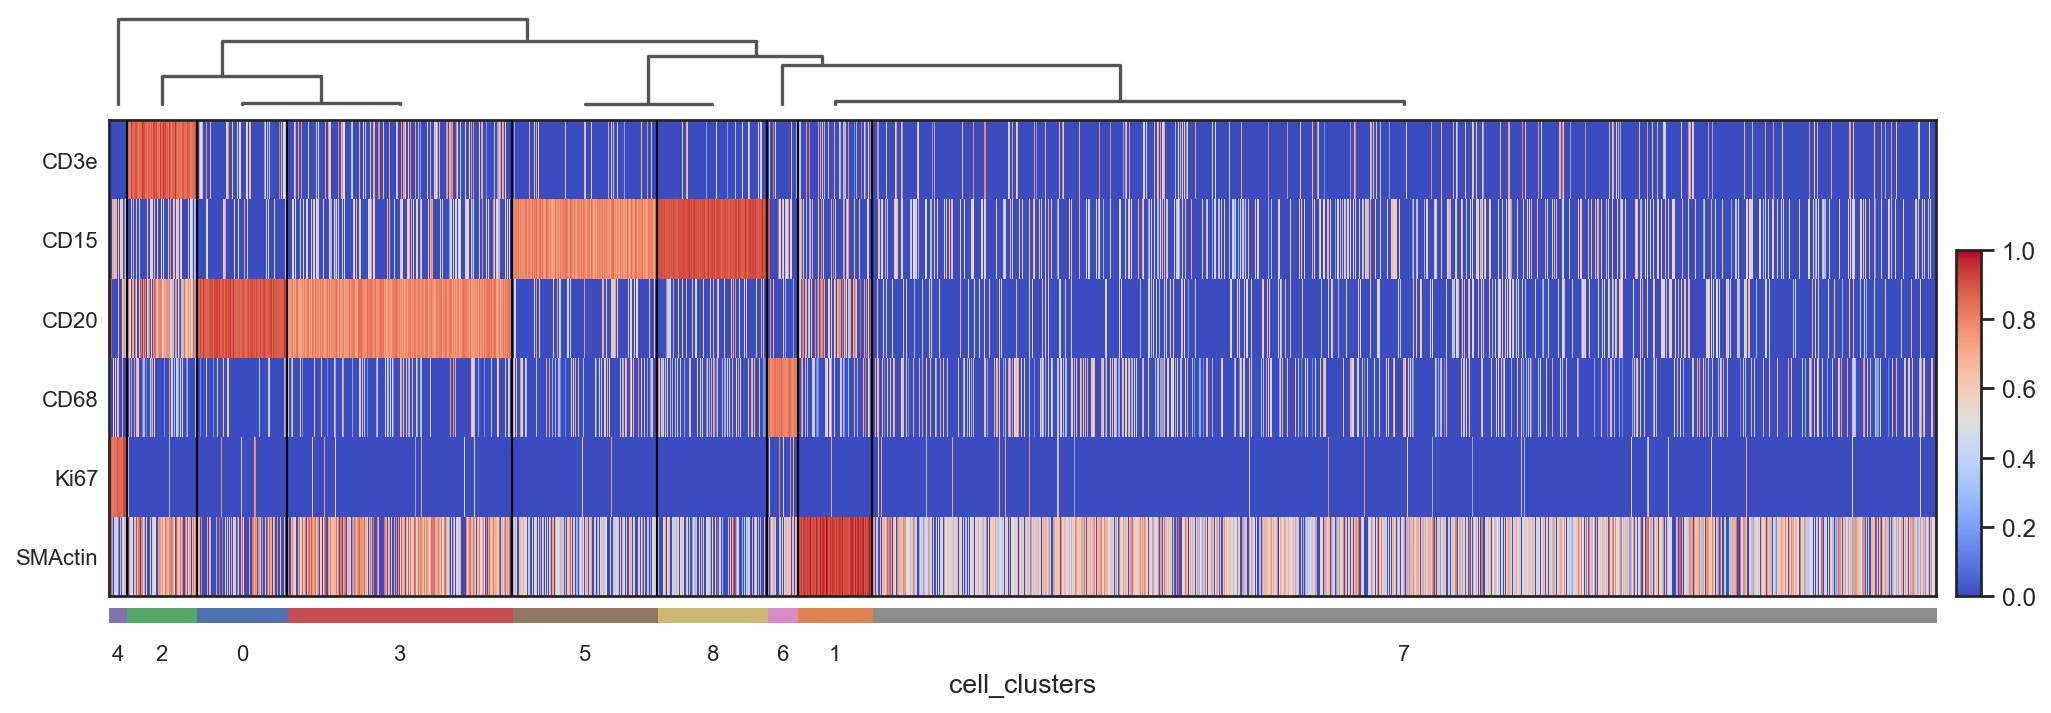

In [92]:
adata_cell.obs['cell_clusters'] = adata_cell.obs['cell_clusters'].astype('category')
sc.tl.dendrogram(adata_cell, groupby='cell_clusters')
sc.pl.heatmap(adata_cell, var_names=adata_cell.var_names, log=True, groupby="cell_clusters", dendrogram=True,use_raw=False,standard_scale='var',swap_axes=True, cmap='coolwarm', figsize=(15, 5))

In [96]:
sc.pp.neighbors(adata_cell, n_neighbors=10, n_pcs=2)
sc.tl.paga(adata_cell, groups='cell_clusters')
sc.tl.umap(adata_cell, min_dist=0.05, spread=1.5, init_pos='paga')

ValueError: Plot PAGA first, so that adata.uns['paga']with key 'pos'.

In [94]:
from matplotlib.pyplot import rc_context

In [95]:
with rc_context({"figure.figsize": (9, 9),'axes.titlesize':25,'axes.labelsize':20, 'xtick.labelsize':20, 'ytick.labelsize':20, 'legend.fontsize':20, 'legend.markerscale':2}):
    ax = sc.pl.paga(adata_cell, fontsize=15, fontoutline= 2, node_size_scale=8, cmap='tab20', show=False)
    sc.pl.paga(adata_cell, fontsize=15, fontoutline= 2, node_size_scale=8, cmap='tab20', ax=ax)
    ax = sc.pl.umap(adata_cell, color=[ 'CD3e', 'CD15', 'CD20', 'CD68', 'SMActin', 'cell_clusters'],
        legend_loc="on data",
        legend_fontsize=12,
        legend_fontoutline=2,
        frameon=False, color_map='viridis', add_outline=True, size=6, show=False)
    sc.pl.umap(adata_cell, color=[ 'CD3e', 'CD15', 'CD20', 'CD68', 'SMActin', 'cell_clusters'],
        legend_loc="on data",
        legend_fontsize=12,
        legend_fontoutline=2,
        frameon=False, color_map='viridis', add_outline=True, size=6, ax=ax)

KeyError: 'paga'

In [ ]:
adata_cell.obsm['X_spatial'] = adata_cell.obs[['X_centroid','Y_centroid']].values
fig,ax=plt.subplots(1,1,figsize=(8,8))
ax.invert_yaxis()
ax.axis('off')
sc.pl.scatter(adata_cell, basis='spatial',color=['cell_clusters'], ax=ax, size=4, legend_fontsize='x-large',
              alpha=0.9, color_map='tab20')

In [ ]:

adata_cell_cluster.obs['cell_clusters'] = adata_cell_cluster.obs['cell_clusters'].astype(str)
adata_cell_cluster = sm.hl.rename(adata_cell_cluster, rename={'B cells':['0', '3'], 'Neutrophils':['5', '8'], 'Macrophages': ['6'], 'Smooth Muscle Cells': ['1']},  from_column='cell_clusters', to_column='phenotype')

In [77]:
adata_cell.X = adata_cell.X.astype(np.uint16)
adata_cell.obs['imageid'] = '1904_CC2B'
adata_cell = sm.pp.rescale(adata_cell, gate=None, imageid='imageid')
# sc.pp.filter_cells(adata_cell, min_counts=100)

Running GMM for image: 1904_CC2B
Applying GMM to markers: CD3e, CD15, CD20, CD68, Ki67, SMActin

Scaling Image: 1904_CC2B
Scaling CD3e (gate: 5.589)
Scaling CD15 (gate: 6.558)
Scaling CD20 (gate: 7.018)
Scaling CD68 (gate: 3.353)
Scaling Ki67 (gate: 5.995)
Scaling SMActin (gate: 6.297)


In [ ]:
marker_genes_dict = {
    "B cell": ["CD20"],

    "T cell": ["CD3e"],

    "Neutrophil": ["CD15"],
    "Macrophage": ["CD68"],

    "Smooth Muscle": ["SMActin"]
}   
sc.pl.dotplot(adata, marker_genes_dict, expression_cutoff=0.36,log=True, groupby="leiden", dendrogram=True,use_raw=False,vcenter=0.65,standard_scale='var', cmap="viridis")